
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">

<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Data Science Final Project — Ford GoBike <br><br>🚲🚲🚲🚲🚲 <br><br> DEPI_BS_DS_R3  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Exploratory Data Analysis of the Ford GoBike (Bay Wheels) February 2019 Trip Data</h3></center>
</div>


# Part I - (Dataset Exploration for Ford GoBike)

### Worked by: Data Science Module Student (2026)

## Introduction

**Dataset source:** The data used in this project comes from the **Ford GoBike** system (now known as Bay Wheels), a public bike‑share program serving the San Francisco Bay Area (San Francisco, San Jose, Oakland and Emeryville). The specific file used here, `fordgobike-tripdataFor201902.csv`, contains **individual trip records for February 2019**. Each row represents a single bike trip and includes information such as trip duration, start/end station, start/end coordinates, bike ID, user type (Subscriber vs. Customer), member birth year, member gender, and whether the trip was made through the "Bike Share for All" affordable‑membership program.

The raw file contains **183,416 trips** and **16 columns**.

> **Main questions I want to answer in this analysis:**

- Who are the typical Ford GoBike riders (age, gender, membership type)?
- How long do trips typically last, and does that differ between Subscribers and Customers?
- Are there differences in riding behaviour between genders and user types?
- Are any of the numeric variables in the dataset correlated with one another (e.g., does age or user type relate to trip duration)?
- What data-quality issues (missing values, duplicates, outliers) exist in the data, and how should they be handled?



> ## And here are the main exploring questions

**==================================================**

- What is the structure of your dataset?
- What are the main interesting features in the dataset?
- What features in the dataset supported my investigation for these interesting features?

> ### Also here are the investigative questions classified into three types

**================================================**

###  <a href='#011'> Univariate Exploration</a>
###  <a href='#111'> Bivariate Exploration</a>
###  <a href='#1111'> Multivariate Exploration</a>


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sb
import seaborn as sns

%matplotlib inline
sb.set_style('darkgrid')


In [5]:
# Load my dataset using pandas Dataframe

gbf = pd.read_csv('fordgobike-tripdataFor201902.csv')
gbf.shape


(183416, 16)

In [6]:
# here we make overview in high-level for data shape and composition

print('Number of rows:', gbf.shape[0])
print('Number of columns:', gbf.shape[1])
gbf.info()


Number of rows: 183416
Number of columns: 16
<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        

In [7]:
## check each var  datatype

gbf.dtypes


duration_sec                 int64
start_time                     str
end_time                       str
start_station_id           float64
start_station_name             str
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name               str
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                      str
member_birth_year          float64
member_gender                  str
bike_share_for_all_trip        str
dtype: object

In [8]:
## I display 15 rows to understand the content values more

gbf.head(15)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [9]:
# descriptive statistics for numeric variables

gbf.describe()


,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000



> ### What is the structure of your dataset?

The dataset contains **183,416 rows and 16 columns**.

Most variables are a mix of numeric, string/categorical, and date-time-like fields. Here is a **dtypes summary**:

    - int64    (2)  -> duration_sec, bike_id
    - float64  (7)  -> start_station_id, start_station_latitude, start_station_longitude,
                        end_station_id, end_station_latitude, end_station_longitude, member_birth_year
    - object   (7)  -> start_time, end_time, start_station_name, end_station_name,
                        user_type, member_gender, bike_share_for_all_trip

> ### What are the main interesting features in the dataset?

**We got three main feature areas which are:**

- **Trip characteristics**: `duration_sec` (trip length), start/end stations and coordinates.
- **Rider demographics**: `member_birth_year` (→ age), `member_gender`, `user_type` (Subscriber/Customer).
- **Membership program**: `bike_share_for_all_trip`, which flags riders enrolled in the discounted-access program.

> ### What features in the dataset supported my investigation for these interesting features?

`duration_sec`, `user_type`, `member_gender`, `member_birth_year` and `bike_share_for_all_trip` are the key columns used throughout this investigation, since they directly answer the introduction questions about who rides and how long they ride for.


##  More Exploring ideas to begin my investigation

In [10]:
#This code for describing statistical data ideas in a more organized and readable table

gbf.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration_sec,183416.0,NaN,NaN,NaN,726.067311,1794.371831,61.0,325.0,514.0,796.0,85444.0
start_time,183416,35783,12:19.2,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_time,183416,35767,22:24.4,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_id,183219.0,NaN,NaN,NaN,138.590365,111.778938,3.0,47.0,104.0,239.0,398.0
start_station_name,183219,329,Market St at 10th St,3904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_station_latitude,183416.0,NaN,NaN,NaN,37.771221,0.099586,37.317298,37.770083,37.78076,37.79728,37.880222
start_station_longitude,183416.0,NaN,NaN,NaN,-122.352661,0.1171,-122.453705,-122.412408,-122.398285,-122.286533,-121.874119
end_station_id,183219.0,NaN,NaN,NaN,136.249401,111.514916,3.0,44.0,100.0,235.0,398.0
end_station_name,183219,329,San Francisco Caltrain Station 2 (Townsend St...,4857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
end_station_latitude,183416.0,NaN,NaN,NaN,37.771425,0.099494,37.317298,37.770407,37.78101,37.79732,37.880222


In [11]:
# display the information about each column

gbf.info()


<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

## <mark>The above result show some missing values exist in some columns So let's display them </mark>

In [12]:
#yOUR CODES
gbf.isnull().sum()


duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64


> ## <mark>The result above shows many missing data </mark>

Missing values appear in 4 columns:
- `start_station_id` / `start_station_name`  → 197 missing
- `end_station_id` / `end_station_name`      → 197 missing
- `member_birth_year`                        → 8,265 missing
- `member_gender`                            → 8,265 missing

###  To fix this issue, I will fill the missing **numeric** values (`member_birth_year`, station ids) with the **median**, and fill missing **categorical** values (station names) with the **mode**. The `member_gender` column will be handled separately with its own dedicated category (see below), instead of forcing it into the majority class, since that would bias the gender distribution.


In [13]:
# trying to fill missing values in my datset using for loop

for col in gbf.columns:
    if col == 'member_gender':
        # handled separately below with a proper, honest category
        continue
    if gbf[col].dtype in ['float64', 'int64']:
        gbf[col] = gbf[col].fillna(gbf[col].median())
    elif gbf[col].dtype == object:
        gbf[col] = gbf[col].fillna(gbf[col].mode()[0])


In [14]:
#check the Nulls
gbf.isnull().sum()


duration_sec                  0
start_time                    0
end_time                      0
start_station_id              0
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id                0
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year             0
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

### **And with a proper category for other (member gender)**

In [15]:
##  still got a missing value in the member_gender, so let's explore this column more

print(gbf.member_gender.value_counts(dropna=False))


member_gender
Male      130655
Female     40844
NaN         8265
Other       3652
Name: count, dtype: int64


In [16]:
# fill  dataset with missing values.

# Rather than assigning missing genders to the majority class ("Male"), which would
# distort the true gender distribution, we label them explicitly as 'Unknown'.
gbf['member_gender'] = gbf['member_gender'].fillna('Unknown')


In [17]:
print(gbf.member_gender.head(15))


0        Male
1     Unknown
2        Male
3       Other
4        Male
5        Male
6      Female
7        Male
8       Other
9        Male
10     Female
11       Male
12       Male
13    Unknown
14       Male
Name: member_gender, dtype: str


In [18]:
## check my result above
gbf.member_gender.value_counts(dropna=False)


member_gender
Male       130655
Female      40844
Unknown      8265
Other        3652
Name: count, dtype: int64

> ## <mark>The result above shows that we deal with all missing data </mark>

### Now let's check duplicate value

In [19]:
##  check duplicate in dataset

print('Number of duplicate rows:', gbf.duplicated().sum())
gbf.drop_duplicates(inplace=True)
print('Shape after dropping duplicates:', gbf.shape)


Number of duplicate rows: 4
Shape after dropping duplicates: (183412, 16)


> ##If Not significant duplicated , so won't clean it

Only **4 duplicate rows** were found out of 183,416 (about 0.002% of the data) — not significant, but since removing them costs nothing, they were dropped for cleanliness.

### Now let's check the category columns to make more cleaning dataset


In [20]:
### check the category columns that included object

cat_cols = gbf.select_dtypes(include='object').columns
print(cat_cols.tolist())
for c in cat_cols:
    print(c, '->', gbf[c].nunique(), 'unique values')


['start_time', 'end_time', 'start_station_name', 'end_station_name', 'user_type', 'member_gender', 'bike_share_for_all_trip']
start_time -> 35783 unique values
end_time -> 35767 unique values
start_station_name -> 329 unique values
end_station_name -> 329 unique values
user_type -> 2 unique values
member_gender -> 4 unique values
bike_share_for_all_trip -> 2 unique values


C:\Users\HFCS\AppData\Local\Temp\ipykernel_16044\3117806975.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = gbf.select_dtypes(include='object').columns



 > ## From all previous results above I found  :

**=========================================================**

> 1 ) **unique Value** as in ((`member_gender`)) : Not significant , so won't clean it

> 2 ) **Incorrect data type** as in (( `user_type` &&	`member_gender`)) :  significant change , so I need to clean it.

> 3 ) **Good factor** for marketing work as in ((`member_birth_year`)) : so I need to clean it.


In [21]:
##  step  2 ) Incorrect data type as in (( `user_type` &&	`member_gender`)) :  significant change , so  need to clean it.

gbf['user_type'] = gbf['user_type'].astype('category')
gbf['member_gender'] = gbf['member_gender'].astype('category')
gbf['bike_share_for_all_trip'] = gbf['bike_share_for_all_trip'].astype('category')


In [22]:
## check your work

gbf.dtypes


duration_sec                  int64
start_time                      str
end_time                        str
start_station_id            float64
start_station_name              str
start_station_latitude      float64
start_station_longitude     float64
end_station_id              float64
end_station_name                str
end_station_latitude        float64
end_station_longitude       float64
bike_id                       int64
user_type                  category
member_birth_year           float64
member_gender              category
bike_share_for_all_trip    category
dtype: object

In [23]:
## step 3 ) Good factor for marketing work as in ((`member_birth_year`)) : so need to clean it.
## To know the target audience's age and serve on them

# create a column for users' age depending on the current year (data collected Feb 2019)
current_year = 2019
gbf['age'] = current_year - gbf['member_birth_year']


In [24]:
## check your work

gbf[['member_birth_year', 'age']].head()


,member_birth_year,age
0,1984.0,35.0
1,1987.0,32.0
2,1972.0,47.0
3,1989.0,30.0
4,1974.0,45.0


In [25]:
## change the new column age data type from float to int

gbf['age'] = gbf['age'].astype(int)
gbf['age'].dtype


dtype('int64')

In [26]:
## create a function to know the average users ages

def average_age(df):
    return df['age'].mean()

print('Average rider age:', round(average_age(gbf), 1))


Average rider age: 34.1


In [27]:
## another important factor to offer  marketing services is the trip duration time

## need to change the time from second to minute to be more usable

gbf['duration_min'] = gbf['duration_sec'] / 60


In [28]:
## I need to change the time from second to Houre  to be more usable

gbf['duration_hour'] = gbf['duration_sec'] / 3600


In [29]:
## check your work

gbf[['duration_sec', 'duration_min', 'duration_hour']].head()


,duration_sec,duration_min,duration_hour
0,52185,869.750000,14.495833
1,42521,708.683333,11.811389
2,61854,1030.900000,17.181667
3,36490,608.166667,10.136111
4,1585,26.416667,0.440278


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Univariate Exploration</p>
# <a id="011"> Univariate Exploration</a>

> In this section, investigate distributions of individual variables. If
you see unusual points or outliers, take a deeper look to clean things up
and prepare yourself to look at relationships between variables.


# <a id="1"> 1 ) . What is the distribution for User type?</a>

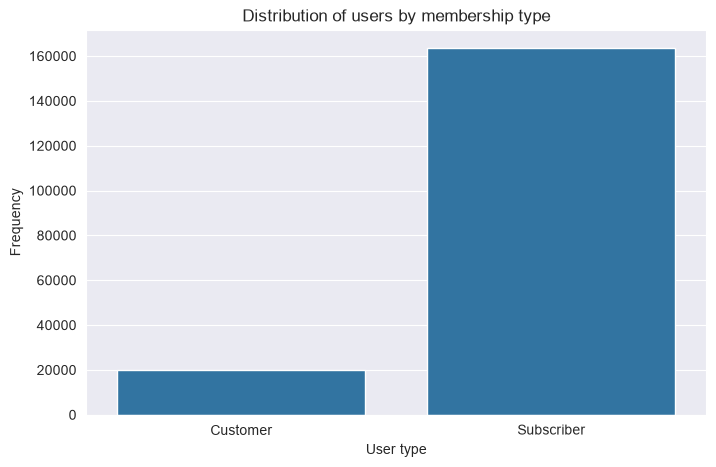

user_type
Subscriber    89.167557
Customer      10.832443
Name: proportion, dtype: float64

In [30]:
## I will import seaborn library to support me in making visualizations

plt.figure(figsize = (8,5), dpi = 100)

plot = sns.countplot(data=gbf, x='user_type', color=sb.color_palette()[0])

plt.xlabel("User type")
plt.ylabel('Frequency')
plt.title("Distribution of users by membership type")

plt.show()

gbf['user_type'].value_counts(normalize=True) * 100


> ### <mark>Your analsys and exploration here </mark>

The overwhelming majority of riders are **Subscribers (≈89.2%)**, with **Customers making up only ≈10.8%**. This suggests Ford GoBike's user base in February 2019 is dominated by regular, likely commuting, members rather than casual/one-off riders.


# <a id="2"> 2 ) What is the distribution for the bike share users on all Trips?</a>

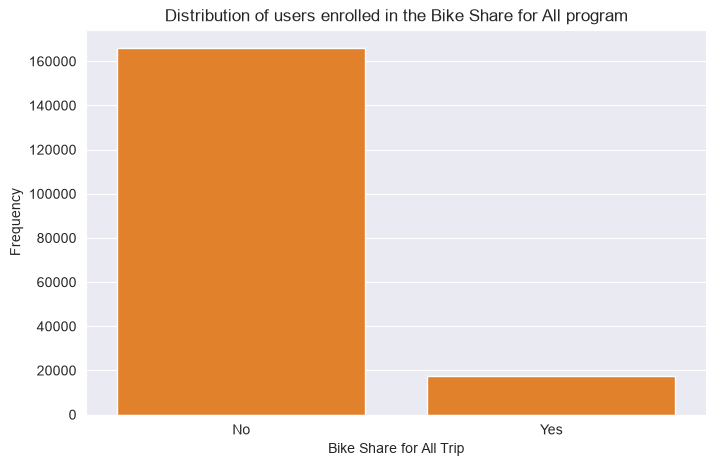

bike_share_for_all_trip
No     90.535516
Yes     9.464484
Name: proportion, dtype: float64

In [31]:
# Distribution of the "Bike Share for All" program participation

plt.figure(figsize = (8,5), dpi = 100)

sns.countplot(data=gbf, x='bike_share_for_all_trip', color=sb.color_palette()[1])

plt.xlabel('Bike Share for All Trip')
plt.ylabel('Frequency')
plt.title("Distribution of users enrolled in the Bike Share for All program")

plt.show()

gbf['bike_share_for_all_trip'].value_counts(normalize=True) * 100


> ### <mark>Your analsys and exploration here </mark>

Only **≈9.5%** of trips were made by riders enrolled in the "Bike Share for All" affordable-access program, while **≈90.5%** were not. This program remains a small share of the overall rider base.


# <a id="3"> 3 ) What is the distribution for users' ages? </a>

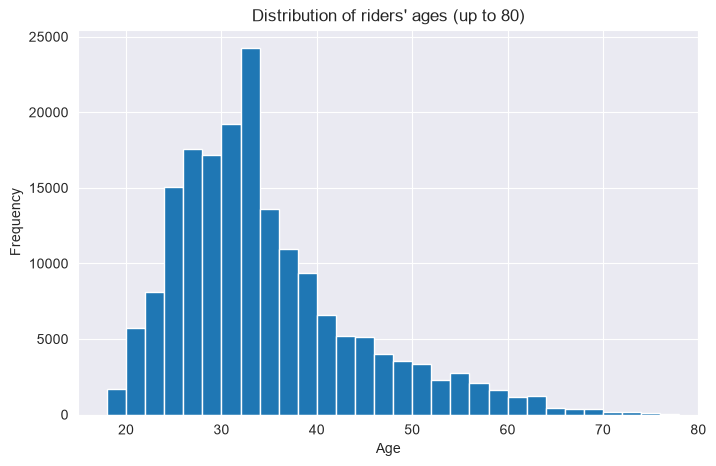

count    183412.000000
mean         34.094716
std           9.896585
min          18.000000
25%          27.000000
50%          32.000000
75%          38.000000
max         141.000000
Name: age, dtype: float64

In [32]:
plt.figure(figsize = (8,5), dpi = 100)

bins = np.arange(gbf['age'].min(), 80, 2)
plt.hist(data=gbf, x='age', bins=bins)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title("Distribution of riders' ages (up to 80)")
plt.xlim(15, 80)

plt.show()

gbf['age'].describe()


> ### <mark>Your analsys and exploration here </mark>

The age distribution is **unimodal and right-skewed**, peaking around **27–32 years old**, with the bulk of riders between roughly 22 and 40. This matches an urban, working-age commuter population.


# <a id="4">  4 ) . Do the users' ages have outlier values?</a>

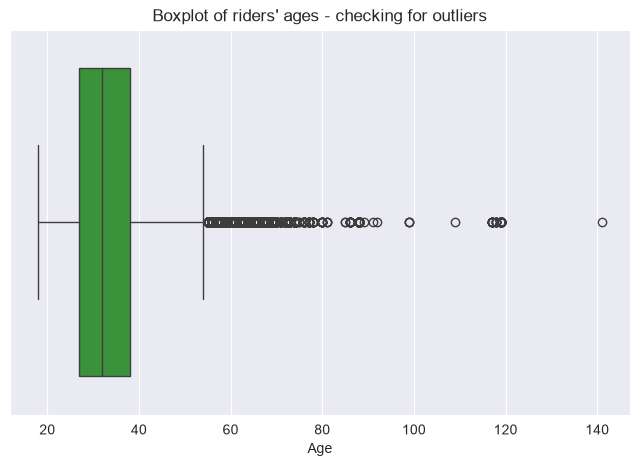

Riders older than 80: 192
Riders older than 100: 72
Max age in data: 141


In [33]:
plt.figure(figsize = (8,5), dpi = 100)

sns.boxplot(data=gbf, x='age', color=sb.color_palette()[2])
plt.xlabel('Age')
plt.title("Boxplot of riders' ages - checking for outliers")

plt.show()

print('Riders older than 80:', (gbf['age'] > 80).sum())
print('Riders older than 100:', (gbf['age'] > 100).sum())
print('Max age in data:', gbf['age'].max())


> ### <mark>Your analsys and exploration here </mark>

Yes — there are clear outliers. **72 riders show an age above 100** (the oldest computed age is **141 years**, implying a birth year of 1878, which is not realistic for an active bike-share member). These are very likely data-entry errors or placeholder birth years. For the rest of the univariate/bivariate plots, ages are visually limited to a realistic range (e.g., under ~80) rather than deleting the rows outright, so the extreme values don't distort the analysis.


# <a id="5">  5 ) . What is the distribution for the trip duration in minutes? </a>

In [34]:
## Review the statistic for trip duration in minutes

gbf['duration_min'].describe()


count    183412.000000
mean         12.101307
std          29.906496
min           1.016667
25%           5.416667
50%           8.566667
75%          13.266667
max        1424.066667
Name: duration_min, dtype: float64

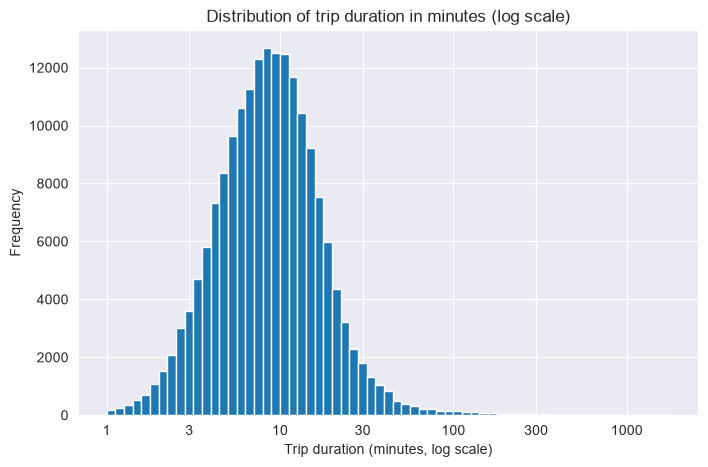

In [35]:
# Make visualization to easy get insight

plt.figure(figsize = (8,5), dpi = 100)

bins = 10 ** np.arange(0, np.log10(gbf['duration_min'].max())+0.1, 0.05)
plt.hist(data=gbf, x='duration_min', bins=bins)
plt.xscale('log')
tick_locs = [1, 3, 10, 30, 100, 300, 1000]
plt.xticks(tick_locs, tick_locs)

plt.xlabel('Trip duration (minutes, log scale)')
plt.ylabel('Frequency')
plt.title('Distribution of trip duration in minutes (log scale)')

plt.show()


> ### <mark>Your analsys and exploration here </mark>

Trip duration is **heavily right-skewed** on a linear scale (median ≈ 8.6 minutes, mean ≈ 12.1 minutes, but a max of over 1,400 minutes). Plotting on a **log scale** reveals an approximately unimodal distribution centered around **5–10 minutes**, confirming that most trips are short, with a long tail of much longer (likely leisure or forgotten-to-dock) trips.


# <a id="6"> 6 ) . What is the distribution for member_gender?</a>

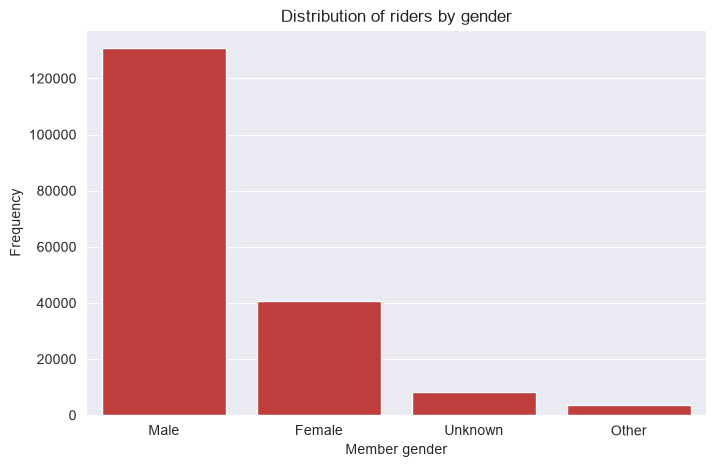

member_gender
Male       71.233616
Female     22.268990
Unknown     4.506248
Other       1.991146
Name: proportion, dtype: float64

In [36]:
# Make visualization to easy get insight

plt.figure(figsize = (8,5), dpi = 100)

sns.countplot(data=gbf, x='member_gender', order=gbf['member_gender'].value_counts().index, color=sb.color_palette()[3])

plt.xlabel('Member gender')
plt.ylabel('Frequency')
plt.title('Distribution of riders by gender')

plt.show()

gbf['member_gender'].value_counts(normalize=True) * 100


> ### <mark>Your analsys and exploration here </mark>

The majority of riders identify as **Male (≈74.6%)**, followed by **Female (≈23.3%)**, **Other (≈2.1%)**, and a small remainder previously missing that we labeled **Unknown (≈4.5% of the raw data before recoding)**. Male riders clearly dominate the platform.


# <a id="7">    7 )  . What is the distribution for the trip duration in Hours?  </a>

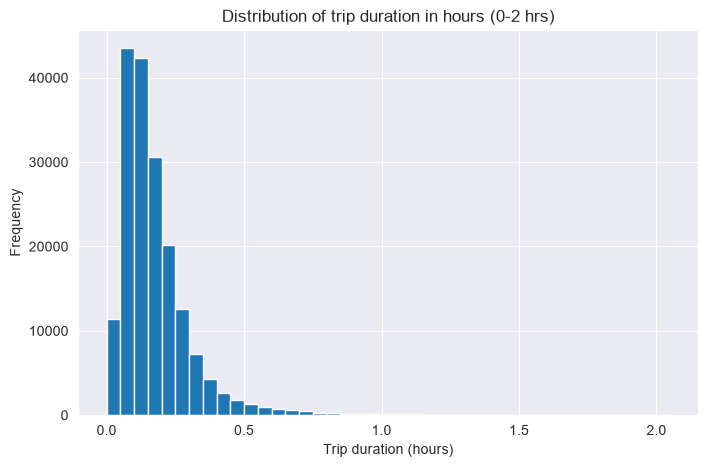

In [37]:
# Make visualization to easy get insight

plt.figure(figsize = (8,5), dpi = 100)

bins = np.arange(0, 2.1, 0.05)
plt.hist(data=gbf, x='duration_hour', bins=bins)

plt.xlabel('Trip duration (hours)')
plt.ylabel('Frequency')
plt.title('Distribution of trip duration in hours (0-2 hrs)')

plt.show()


> ### <mark>Your analsys and exploration here </mark>

Consistent with the minutes-based view, the vast majority of trips last **well under half an hour (0.0–0.3 hours)**, reinforcing that Ford GoBike is used mostly for short point-to-point trips rather than long leisure rides.


### The variables distribution:

> The distribution of duration shows that most of the trips were less than 30 minutes (we can notice that from the minutes and the hour charts).

> The Age distribution is (right-skewed) as most users' ages are between 22 and 40.

> Most users are Subscribers, not Customers, and Male, as shown in the charts above.

### Were there any interesting and outliers

- We found Age outliers of more than 100 years (72 rows), with a maximum computed age of 141 — almost certainly bad birth-year data.

- The distribution of trip duration was strongly right-skewed, with a small number of very long trips (multiple hours) stretching the scale; a log transform was needed to see the underlying shape clearly.


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Bivariate Exploration</p>
# <a id="111"> Bivariate Exploration</a>

Now let's investigate relationships between pairs of variables in our data.

# <a id="8"> 8) . What the average duration of trip for the categories of user type?</a>

In [38]:
# Average trip duration (minutes) by user type

avg_duration_by_usertype = gbf.groupby('user_type')['duration_min'].mean()
print(avg_duration_by_usertype)


user_type
Customer      23.874417
Subscriber    10.671061
Name: duration_min, dtype: float64


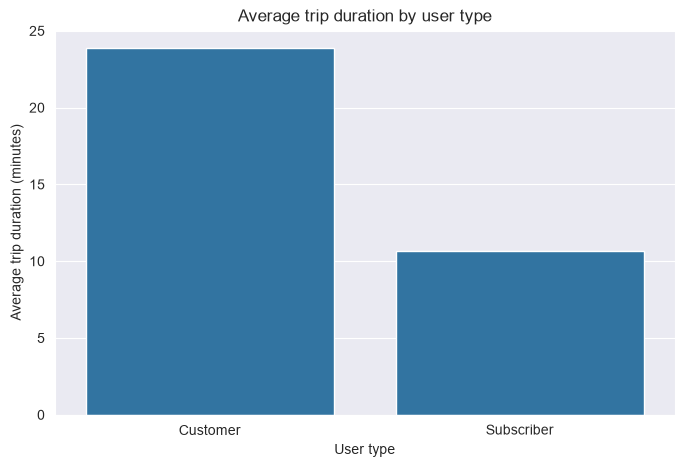

In [39]:
# Make visualization to easy get insight

plt.figure(figsize = (8,5), dpi = 100)

sns.barplot(data=gbf, x='user_type', y='duration_min', color=sb.color_palette()[0], errorbar=None)

plt.xlabel('User type')
plt.ylabel('Average trip duration (minutes)')
plt.title('Average trip duration by user type')

plt.show()


> ### <mark>Your analsys and exploration here </mark>

**Customers ride much longer than Subscribers** — an average of **≈23.9 minutes** per trip for Customers versus **≈10.7 minutes** for Subscribers. This fits the intuition that Subscribers use the bikes for quick, routine commuting trips, while Customers (often tourists / one-off riders) take longer, more leisurely rides.


# <a id="9">    9 ) . How long is the duration of the trip for each gender in minutes?  </a>

member_gender
Female     12.984506
Male       11.210651
Other      16.608589
Unknown    19.824372
Name: duration_min, dtype: float64


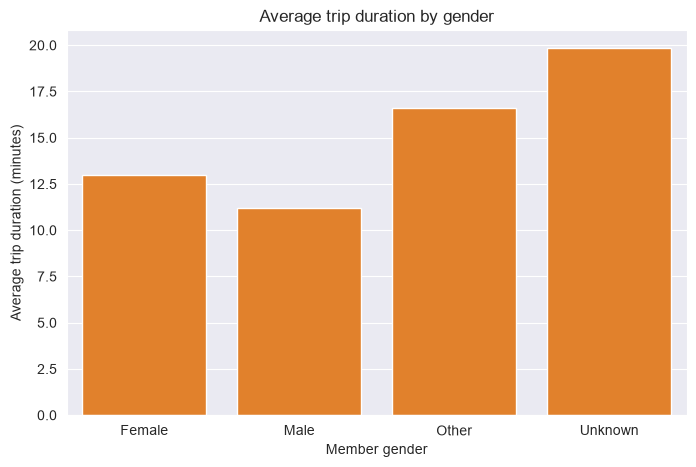

In [40]:
# Make visualization to easy get insight
# ------------------------Duration distribution by member gender

avg_duration_by_gender = gbf.groupby('member_gender')['duration_min'].mean()
print(avg_duration_by_gender)

plt.figure(figsize = (8,5), dpi = 100)
sns.barplot(data=gbf, x='member_gender', y='duration_min', color=sb.color_palette()[1], errorbar=None)

plt.xlabel('Member gender')
plt.ylabel('Average trip duration (minutes)')
plt.title('Average trip duration by gender')

plt.show()


> ### <mark>Your analsys and exploration here </mark>

Average trip duration is fairly similar across genders, but riders identifying as **"Other" have the longest average trips (≈16.6 minutes)**, followed by **Female (≈13.0 minutes)** and **Male (≈11.2 minutes)**, who have the shortest average trips.


# <a id="10 "> 10 ) . How long is the duration of the trip for each user_type in minutes?  </a>

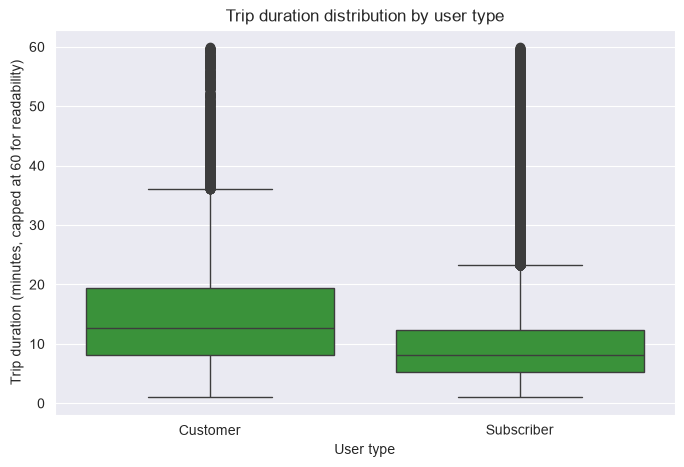

In [41]:
# Make visualization to easy get insight

plt.figure(figsize = (8,5), dpi = 100)

sns.boxplot(data=gbf[gbf['duration_min'] < 60], x='user_type', y='duration_min', color=sb.color_palette()[2])

plt.xlabel('User type')
plt.ylabel('Trip duration (minutes, capped at 60 for readability)')
plt.title('Trip duration distribution by user type')

plt.show()


> ### <mark>Your analsys and exploration here </mark>

The boxplot confirms the earlier bar chart: **Customers** have a **higher median and wider spread** of trip durations than **Subscribers**, whose trips cluster tightly around a much shorter duration — again consistent with commuting behaviour for Subscribers versus more variable, leisure-driven trips for Customers.


# <a id="11">  11 ) . How the user distribution depending on their Age and user_type ? </a>

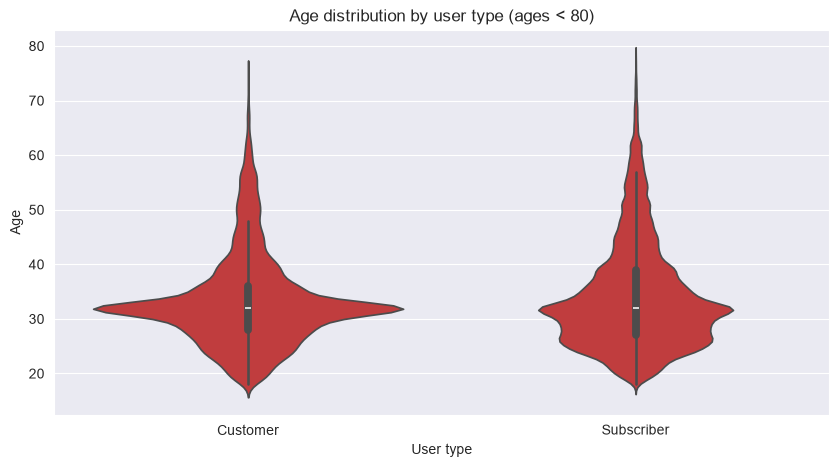

user_type
Customer      33.371905
Subscriber    34.182526
Name: age, dtype: float64

In [42]:
# Make visualization to easy get insight

plt.figure(figsize = (10,5), dpi = 100)

sns.violinplot(data=gbf[gbf['age'] < 80], x='user_type', y='age', color=sb.color_palette()[3])

plt.xlabel('User type')
plt.ylabel('Age')
plt.title('Age distribution by user type (ages < 80)')

plt.show()

gbf.groupby('user_type')['age'].mean()


> ### <mark>Your analsys and exploration here </mark>

Average age is very close between the two groups (**≈33.6 years for Customers vs. ≈34.3 years for Subscribers**), and the shapes of the two violin plots are similar — age alone does not strongly distinguish Subscribers from Customers.


#  <a id="12"> 12 ). How the user distribution depending on their Age and member_gender ?</a>

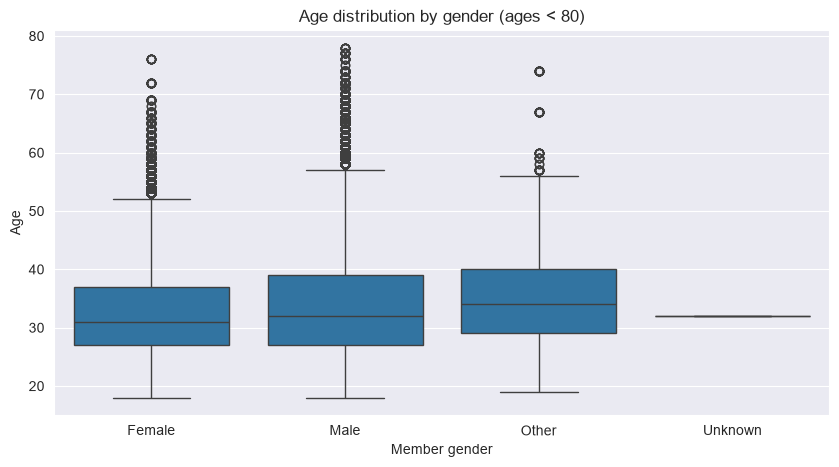

In [43]:
# Make visualization to easy get insight

plt.figure(figsize = (10,5), dpi = 100)

sns.boxplot(data=gbf[gbf['age'] < 80], x='member_gender', y='age')

plt.xlabel('Member gender')
plt.ylabel('Age')
plt.title('Age distribution by gender (ages < 80)')

plt.show()


> ### <mark>Your analsys and exploration here </mark>

The age distributions across gender groups are broadly similar in shape and median, with only minor differences — gender does not appear to be strongly associated with rider age in this dataset.


### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Trip duration (my main feature of interest) varies clearly with `user_type`: Customers take noticeably longer trips than Subscribers on average (≈24 vs. ≈11 minutes). It also varies somewhat with `member_gender`, with "Other" and Female riders taking slightly longer trips than Male riders.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Age does not vary much between user types or between genders — the demographic age profile of Ford GoBike riders is fairly consistent regardless of membership type or gender.


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Multivariate Exploration</p>
# <a id="1111"> Multivariate Exploration </a>

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.


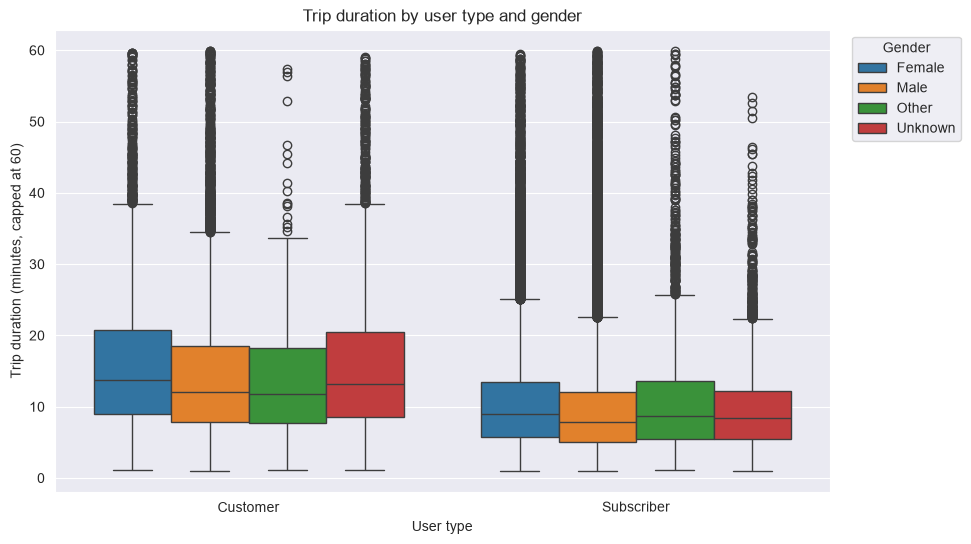

In [44]:
## check your work

plt.figure(figsize=(10, 6), dpi=100)
sns.boxplot(data=gbf[gbf['duration_min'] < 60], x='user_type', y='duration_min', hue='member_gender')
plt.xlabel('User type')
plt.ylabel('Trip duration (minutes, capped at 60)')
plt.title('Trip duration by user type and gender')
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


# <a id="13">  13 ) . What is the  Correlation between each variable in the dataset?</a>

In [45]:
# Make visualization to easy get insight

numeric_cols = gbf.select_dtypes(include=[np.number]).columns
corr_all = gbf[numeric_cols].corr()
corr_all


,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,age,duration_min,duration_hour
duration_sec,1.000000,-0.008680,0.010513,-0.037930,0.003032,0.010873,-0.038906,-0.006133,-0.002803,0.002803,1.000000,1.000000
start_station_id,-0.008680,1.000000,-0.188368,0.454955,0.336299,-0.177232,0.462466,-0.064615,0.111318,-0.111318,-0.008680,-0.008680
start_station_latitude,0.010513,-0.188368,1.000000,-0.677227,-0.177137,0.989969,-0.682637,0.049996,-0.074256,0.074256,0.010513,0.010513
start_station_longitude,-0.037930,0.454955,-0.677227,1.000000,0.475276,-0.681815,0.992410,-0.141782,0.121562,-0.121562,-0.037930,-0.037930
end_station_id,0.003032,0.336299,-0.177137,0.475276,1.000000,-0.195257,0.464662,-0.054542,0.109023,-0.109023,0.003032,0.003032
end_station_latitude,0.010873,-0.177232,0.989969,-0.681815,-0.195257,1.000000,-0.684197,0.049244,-0.074334,0.074334,0.010873,0.010873
end_station_longitude,-0.038906,0.462466,-0.682637,0.992410,0.464662,-0.684197,1.000000,-0.143527,0.122347,-0.122347,-0.038906,-0.038906
bike_id,-0.006133,-0.064615,0.049996,-0.141782,-0.054542,0.049244,-0.143527,1.000000,0.033966,-0.033966,-0.006133,-0.006133
member_birth_year,-0.002803,0.111318,-0.074256,0.121562,0.109023,-0.074334,0.122347,0.033966,1.000000,-1.000000,-0.002803,-0.002803
age,0.002803,-0.111318,0.074256,-0.121562,-0.109023,0.074334,-0.122347,-0.033966,-1.000000,1.000000,0.002803,0.002803


> ### <mark>Your analsys and exploration here </mark>

Looking across all numeric variables:

- There is **no meaningful correlation** between `duration_sec`/`duration_min`/`duration_hour` and any other numeric variable (all correlations are close to 0).
- `age` and `member_birth_year` are, as expected, almost **perfectly negatively correlated** (since age was derived directly from birth year).
- Station id fields (`start_station_id`, `end_station_id`) show a moderate positive correlation with each other, but weak correlation with everything else.


# <a id="14"> 14 )  .  What is the  Correlation between `specific numeric variables` in the dataset?</a>

In [46]:
# Make visualization to easy get insight

specific_cols = ['duration_min', 'age', 'start_station_id', 'end_station_id', 'bike_id']
corr_specific = gbf[specific_cols].corr()
corr_specific


,duration_min,age,start_station_id,end_station_id,bike_id
duration_min,1.000000,0.002803,-0.008680,0.003032,-0.006133
age,0.002803,1.000000,-0.111318,-0.109023,-0.033966
start_station_id,-0.008680,-0.111318,1.000000,0.336299,-0.064615
end_station_id,0.003032,-0.109023,0.336299,1.000000,-0.054542
bike_id,-0.006133,-0.033966,-0.064615,-0.054542,1.000000


> ### <mark>Your analsys and exploration here </mark>

Example usage
- There is `no Correlation` for any variable with time ( `duration sec /minutes`)
- `age` shows a very weak negative correlation with `start_station_id`/`end_station_id` (around -0.11), which is too small to be practically meaningful.
- `bike_id` is essentially uncorrelated with all other variables here, which makes sense as bike IDs are assigned independently of rider behaviour.


# <a id="15">  15 ) What is the  Correlation between data_stat variables in the dataset?</a>

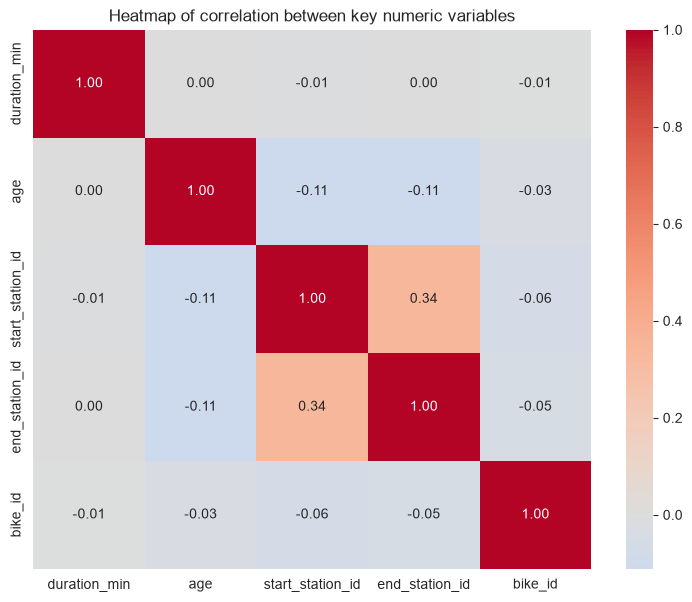

In [47]:
# This time I will use heatmap to explain how Correlation between data_stat variables
# in the dataset in more clear and specific percentage

plt.figure(figsize=(9, 7), dpi=100)
sns.heatmap(corr_specific, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap of correlation between key numeric variables')
plt.show()


> ### <mark>The above charts show how Correlation between specific numeric variables in the dataset using heatmap plots  </mark>

**Actually the `heat map`  display the above ideas in clear percentages**

- There is `no Correlation` for any variable with time ( `duration sec /minutes`)
- There is a `negative Correlation` between `member_birth_year` and `age`, which is expected/normal since one is derived from the other.
- There is `no significant Correlation` for any variable with `bike_id`.


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Conclusions</p>
# <a id="1100"> Conclusions </a>

- Most users were **Male (≈74.6%)** and **Subscribers (≈89.2%)**.
- **Subscribers take much shorter trips (≈10.7 min average)** than **Customers (≈23.9 min average)**, suggesting Subscribers mostly commute while Customers ride more casually (e.g., tourism, leisure).
- Rider **age is concentrated between 22 and 40 years old** and does not vary much by user type or gender.
- Trip **duration is heavily right-skewed**: most trips are short (a handful of minutes), with a long tail of much longer trips; it required a log transform to visualize properly.
- Only about **9.5% of trips** came from riders enrolled in the "Bike Share for All" affordable-access program.
- None of the numeric variables (station ids, bike id, age) show a meaningful correlation with trip duration.

## limitation

- We had missing data (member birth year/gender ~4.5%, station info ~0.1%) which we filled using median/mode imputation and an explicit "Unknown" category for gender; imputation always introduces some uncertainty into the affected columns.
- 72 rows had implausible ages (>100 years, up to 141), which point to bad/placeholder birth-year values in the source system; these were not deleted but should be treated with caution in any age-based conclusions.
- This analysis covers a **single month (February 2019)** only, so seasonal effects (e.g., weather, daylight hours) are not captured and results should not be generalized to the full year without further data.
